# Firing–Current Curve of the LIF Neuron

The previous notebook extended the passive membrane model by adding a firing threshold, voltage reset, and absolute refractory period. This notebook studies how the resulting LIF neuron responds to different constant injected currents.

The main goals are to:

- implement a reusable numerical LIF simulator,
- derive the rheobase current,
- derive the analytical firing-rate equation,
- construct the firing–current (F–I) curve,
- validate the numerical simulation against the analytical prediction, and
- identify the upper firing-rate limit imposed by the refractory period.


## Numerical simulator

The threshold, reset, and refractory dynamics developed in the previous notebook are packaged into a reusable simulation function. For each injected current, the firing rate is estimated from the mean interval between consecutive spikes.

In [7]:
import numpy as np
import matplotlib.pyplot as plt 


def simulate_lif(i0,
                t_end = 0.3, dt = 1e-4, t_refractory = 2 * 1e-3,
                v_threshold = -50e-3, v_reset = -65e-3, e_l = -65e-3, v0 = -65e-3,
                r_m = 100e6, c_m = 200e-12):

    tau = r_m * c_m
    v_inf = i0 * r_m + e_l

    def dv(v, v_inf, tau):
        return -(v - v_inf)/tau
    
    spike_times = []
    refractory_cond = 0

    time = np.arange(0, t_end, dt)
    v = np.empty_like(time)
    v[0] = v0

    for i in range(time.shape[0] - 1):

        if time[i] < refractory_cond:
            v[i+1] = v[i]
            continue

        dvdt = dv(v[i], v_inf, tau)
        v[i+1] = v[i] + dt * dvdt

        if v[i+1] >= v_threshold:
            v[i+1] = v_reset
            spike_times.append(time[i + 1])
            refractory_cond = time[i+1] + t_refractory

    I_rh = (v_threshold - e_l)/r_m
    spike_times = np.array(spike_times)

    if i0 <= I_rh:
        Frequency = 0

    elif spike_times.size >= 2:
        T_total = np.mean(np.diff(spike_times))
        Frequency = 1 / T_total

    else:
        Frequency = np.nan

    return time, v, spike_times, t_refractory, v_threshold, v_inf, Frequency


## Analytical F–I curve

The previous notebook derived the firing-rate equation for a constant injected current. Here, that result is evaluated over a range of currents to construct the analytical F–I curve.

The neuron fires only above the rheobase current:

$$
I_{\mathrm{rh}} = \frac{V_{\mathrm{threshold}}-E_L}{R_m}
$$

For $I_0>I_{\mathrm{rh}}$, the firing rate is:

$$ \large
f(I_0) = \begin{cases}

        0 & \text {if} & I_0 \le I_{rh} \\[0.5cm]

        \frac{1}{T_{ref} + \tau_m \, ln(\frac{V_{reset} - E_L-R_mI_0}{(V_{threshold} - E_L-R_mI_0})} & \text {if} & I_0 > I_{rh}

        \end{cases}
$$

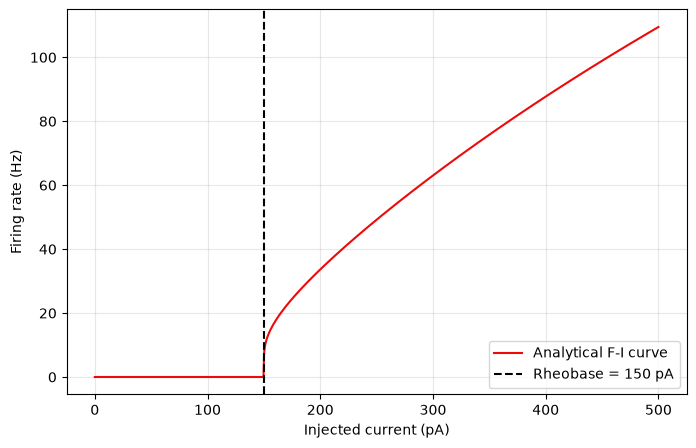

In [9]:
e_l = -65 * 1e-3
v_reset = -65 * 1e-3
v_threshold = -50 * 1e-3
r_m = 100 * 1e6
c_m = 200 * 1e-12
t_refractory = 2 * 1e-3

tau = r_m * c_m
i_rh = (v_threshold - e_l) / r_m


def analytical_firing_rate(i0):

    if i0 <= i_rh:
        return 0.0

    v_inf = i0 * r_m + e_l
    T = tau * np.log((v_reset - v_inf)/(v_threshold - v_inf))
    T_total = T + t_refractory 

    return 1/T_total


currents = np.linspace(0, 500 * 1e-12, 1000)

analytical_rates = np.array([
    analytical_firing_rate(current)
    for current in currents
])


plt.figure(figsize=(8, 5))
plt.plot(currents * 1e12, analytical_rates, label='Analytical F-I curve', color = "#EC0A0A")
plt.axvline(i_rh * 1e12, linestyle = '--', color = 'black', label = f'Rheobase = {i_rh * 1e12:.0f} pA')
plt.xlabel('Injected current (pA)')
plt.ylabel('Firing rate (Hz)')
plt.legend()
plt.grid(alpha = 0.3)
plt.show()


## Numerical validation

Numerical firing rates are measured at selected currents and compared with the analytical prediction. Additional currents are sampled near rheobase, where the firing rate changes most rapidly and numerical threshold detection is most sensitive to the time step.

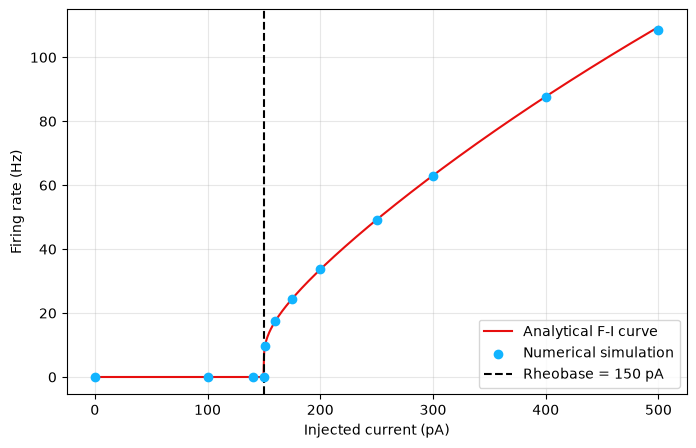

Mean absolute error: 0.0929 Hz
Maximum absolute error: 0.8188 Hz


In [10]:
test_currents = np.array([
    0, 100, 140, 150,
    151, 160, 175, 200,
    250, 300, 400, 500
]) * 1e-12

numerical_rates = []

for current in test_currents:
    time, v, spike_times, t_refractory, v_threshold, v_inf, Frequency = simulate_lif(current, t_end=2, t_refractory=t_refractory, dt = 1e-4)
    numerical_rates.append(Frequency)

numerical_rates = np.array(numerical_rates)

plt.figure(figsize=(8, 5))

plt.plot(
    currents * 1e12,
    analytical_rates,
    color="#E70F0F",
    label='Analytical F-I curve'
)

plt.scatter(
    test_currents * 1e12,
    numerical_rates,
    zorder=3,
    color = "#11B4FF",
    label = 'Numerical simulation'
)

plt.xlabel('Injected current (pA)')
plt.ylabel('Firing rate (Hz)')
plt.axvline(i_rh * 1e12, linestyle = '--', color = 'black', label = f'Rheobase = {i_rh * 1e12:.0f} pA')
plt.legend()
plt.grid(alpha = 0.3)
plt.show()

analytical_test_rates = np.array([analytical_firing_rate(current) for current in test_currents])
absolute_errors = np.abs(analytical_test_rates - numerical_rates)

print(f'Mean absolute error: {np.mean(absolute_errors):.4f} Hz')
print(f'Maximum absolute error: {np.max(absolute_errors):.4f} Hz')


## Results

The numerical simulations closely follow the analytical F–I curve. The mean absolute error is approximately $0.0929\,\mathrm{Hz}$, while the maximum absolute error is approximately $0.8188\,\mathrm{Hz}$.

Below rheobase, the neuron does not fire. Above rheobase, increasing the injected current shortens the charging time and increases the firing rate.

As the current becomes very large, the charging time approaches zero. The refractory period therefore sets the limiting firing rate:

$$
f_{\max}
=
\frac{1}{T_{\mathrm{ref}}}
=
\frac{1}{2\,\mathrm{ms}}
=
500\,\mathrm{Hz}.
$$

The agreement between both methods validates the numerical implementation before it is applied to inputs without analytical solutions.